In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
# This script get the database of events with Odometer that I created in my research.
events=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\queclink_do_not_delete.csv',sep=';') #Edit
events_with_odometer=events[events['odometer'].str.contains('Y')]
df_book_table01=events_with_odometer

In [27]:
raw_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ams\events.csv',sep=',') #Edit
raw_data_columns=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ams\events_columns.csv',sep=',') #Edit
raw_data_columns['Date']='NaN'
raw_data_columns['Message_Type']='NaN'
raw_data_columns['Message_Type_No_Buff']='NaN'
aux_m=[]
aux_m_nb=[]

for i in range(0,raw_data_columns.shape[0]):
    aux_m.append(raw_data_columns.iloc[i,0][6:11])
    #aux_m_nb.append(raw_data_columns.iloc[i,0])
raw_data_columns['Message_Type']=aux_m

raw_data_columns['Message_Type'].value_counts().to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ams\columns.csv')  #Edit
raw_data_columns_aux=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ams\columns.csv')    #Edit
raw_data_columns_aux.info()
df_book_table02=raw_data_columns_aux

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Message_Type  14 non-null     str  
 1   count         14 non-null     int64
dtypes: int64(1), str(1)
memory usage: 356.0 bytes


In [28]:
raw_data_columns['Message_Type'].value_counts()

Message_Type
GTFRI    5234
GTSTT    1287
GTPDP     520
GTIGL     366
GTIGF     185
GTIGN     184
GTSPD     126
GTIDN      20
GTIDF      20
GTHBM      10
GTPNA       4
GTRTL       4
GTDOG       3
GTPFA       3
Name: count, dtype: int64

In [29]:
print("Events from unit: ","\n",df_book_table02)
print("Events with odometer: ","\n",df_book_table01)

Events from unit:  
    Message_Type  count
0         GTFRI   5234
1         GTSTT   1287
2         GTPDP    520
3         GTIGL    366
4         GTIGF    185
5         GTIGN    184
6         GTSPD    126
7         GTIDN     20
8         GTIDF     20
9         GTHBM     10
10        GTPNA      4
11        GTRTL      4
12        GTDOG      3
13        GTPFA      3
Events with odometer:  
    events odometer
0   GTFRI        Y
3   GTIGL        Y
4   GTIGF        Y
5   GTIGN        Y
6   GTSPD        Y
7   GTIDN        Y
8   GTIDF        Y
9   GTHBM        Y
11  GTRTL        Y
12  GTDOG        Y


Analysis

In [30]:
gtfri_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTFRI')]
gtigl_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTIGL')]
gtigf_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTIGF')]
gtign_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTIGN')]
gthbm_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTHBM')]
gttow_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTTOW')]
gtrtl_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTRTL')]
gtdog_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTDOG')]
gtspd_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTSPD')]
gtidn_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTIDN')]
gtidf_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTIDF')]
gthbm_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTHBM')]
gtbtc_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTBTC')]
gtstc_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTSTC')]
gtstt_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTSTT')]

date_gtfri=[]
date_gtigl=[]
date_gtigf=[]
date_gtign=[]
date_gthbm=[]
date_gttow=[]
date_gtrtl=[]
date_gtdog=[]
date_gtspd=[]
date_gtidn=[]
date_gtidf=[]
date_gtbtc=[]
date_gtstc=[]
date_gtstt=[]

km_gtfri=[]
km_gtigl=[]
km_gtign=[]
km_gtigf=[]
km_gtidn=[]
km_gtidf=[]
km_gtdog=[]
km_gtspd=[]
km_gtrtl=[]
km_gthbm=[]
km_gttow=[]
km_gtbtc=[]
km_gtstc=[]
km_gtstt=[]

sp_gtfri=[]
sp_gtigl=[]
sp_gtign=[]
sp_gtigf=[]
sp_gtidn=[]
sp_gtidf=[]
sp_gtdog=[]
sp_gtspd=[]
sp_gtrtl=[]
sp_gthbm=[]
sp_gttow=[]
sp_gtspd=[]
sp_gtbtc=[]
sp_gtstc=[]
sp_gtstt=[]

for i in range(0, gtfri_raw_data.shape[0]):
    date_gtfri.append(str(gtfri_raw_data.iloc[i,13]))    
    km_gtfri.append((float(gtfri_raw_data.iloc[i,20]))*0.621371)
    sp_gtfri.append(gtfri_raw_data.iloc[i,8])
gtfri_raw_data['Date']=date_gtfri
gtfri_raw_data['Km in miles']=km_gtfri
gtfri_raw_data['Speed']=sp_gtfri

for i in range(0, gtigl_raw_data.shape[0]):
    date_gtigl.append(str(gtigl_raw_data.iloc[i,13]))    
    km_gtigl.append((float(gtigl_raw_data.iloc[i,20]))*0.621371)
    sp_gtigl.append(gtigl_raw_data.iloc[i,8])
gtigl_raw_data['Date']=date_gtigl
gtigl_raw_data['Km in miles']=km_gtigl
gtigl_raw_data['Speed']=sp_gtigl

for i in range(0, gtign_raw_data.shape[0]):
    date_gtign.append(str(gtign_raw_data.iloc[i,13]))    
    km_gtign.append((float(gtign_raw_data.iloc[i,20]))*0.621371)
    sp_gtign.append(gtign_raw_data.iloc[i,6])
gtign_raw_data['Date']=date_gtign
gtign_raw_data['Km in miles']=km_gtign
gtign_raw_data['Speed']=sp_gtign

for i in range(0, gtigf_raw_data.shape[0]):
    date_gtigf.append(str(gtigf_raw_data.iloc[i,13]))    
    km_gtigf.append((float(gtigf_raw_data.iloc[i,20]))*0.621371)
    sp_gtigf.append(gtigf_raw_data.iloc[i,6])
gtigf_raw_data['Date']=date_gtigf
gtigf_raw_data['Km in miles']=km_gtigf
gtigf_raw_data['Speed']=sp_gtigf

for i in range(0, gtidn_raw_data.shape[0]):
    date_gtidn.append(str(gtidn_raw_data.iloc[i,12]))    
    km_gtidn.append((float(gtidn_raw_data.iloc[i,20]))*0.621371)
    sp_gtidn.append(gtidn_raw_data.iloc[i,7])    
gtidn_raw_data['Date']=date_gtidn
gtidn_raw_data['Km in miles']=km_gtidn
gtidn_raw_data['Speed']=sp_gtidn

for i in range(0, gtidf_raw_data.shape[0]):
    date_gtidf.append(str(gtidf_raw_data.iloc[i,12]))    
    km_gtidf.append((float(gtidf_raw_data.iloc[i,20]))*0.621371)
    sp_gtidf.append(gtidf_raw_data.iloc[i,7])
gtidf_raw_data['Date']=date_gtidf
gtidf_raw_data['Km in miles']=km_gtidf

for i in range(0, gtdog_raw_data.shape[0]):
    date_gtdog.append(str(gtdog_raw_data.iloc[i,13]))    
    km_gtdog.append((float(gtdog_raw_data.iloc[i,20]))*0.621371)
    sp_gtdog.append(gtdog_raw_data.iloc[i,8])   
gtdog_raw_data['Date']=date_gtdog
gtdog_raw_data['Km in miles']=km_gtdog
gtdog_raw_data['Speed']=sp_gtdog

for i in range(0, gtspd_raw_data.shape[0]):
    date_gtspd.append(str(gtspd_raw_data.iloc[i,13]))    
    km_gtspd.append((float(gtspd_raw_data.iloc[i,20]))*0.621371)
    sp_gtspd.append(gtspd_raw_data.iloc[i,8])    
gtspd_raw_data['Date']=date_gtspd
gtspd_raw_data['Km in miles']=km_gtspd
gtspd_raw_data['Speed']=sp_gtspd

for i in range(0, gtrtl_raw_data.shape[0]):
    date_gtrtl.append(str(gtrtl_raw_data.iloc[i,13]))    
    km_gtrtl.append((float(gtrtl_raw_data.iloc[i,20]))*0.621371)
    sp_gtrtl.append(gtrtl_raw_data.iloc[i,8])
gtrtl_raw_data['Date']=date_gtrtl
gtrtl_raw_data['Km in miles']=km_gtrtl
gtrtl_raw_data['Speed']=sp_gtrtl

for i in range(0, gthbm_raw_data.shape[0]):
    date_gthbm.append(str(gthbm_raw_data.iloc[i,13]))    
    km_gthbm.append((float(gthbm_raw_data.iloc[i,20]))*0.621371)
    sp_gthbm.append(gthbm_raw_data.iloc[i,8])    
gthbm_raw_data['Date']=date_gthbm
gthbm_raw_data['Km in miles']=km_gthbm
gthbm_raw_data['Speed']=sp_gthbm

#For any reason, date is turned into float value.
for i in range(0, gttow_raw_data.shape[0]):
    date_gttow.append(gttow_raw_data.iloc[i,13])
    km_gttow.append((float(gttow_raw_data.iloc[i,20]))*0.621371)
    sp_gttow.append(gttow_raw_data.iloc[i,8])
gttow_raw_data['Date']=str(date_gttow)
gttow_raw_data['Km in miles']=km_gttow
gttow_raw_data['Speed']=sp_gttow

for i in range(0, gtstt_raw_data.shape[0]):
    date_gtstt.append(gtstt_raw_data.iloc[i,13])
    #km_gtstt.append((float(gtstt_raw_data.iloc[i,20]))*0.621371)
    sp_gtstt.append(gtstt_raw_data.iloc[i,5])
gtstt_raw_data['Date']=str(date_gtstt)
#gtstt_raw_data['Km in miles']=km_gtstt
gtstt_raw_data['Speed']=sp_gtstt

value_to_look=input('Type the last date to searh: ')

gtfri_raw_data_wanted=gtfri_raw_data[gtfri_raw_data['Date'].str.contains(value_to_look)]
gtigl_raw_data_wanted=gtigl_raw_data[gtigl_raw_data['Date'].str.contains(value_to_look)]
gtign_raw_data_wanted=gtign_raw_data[gtign_raw_data['Date'].str.contains(value_to_look)]
gtigf_raw_data_wanted=gtigf_raw_data[gtigf_raw_data['Date'].str.contains(value_to_look)]
gtidn_raw_data_wanted=gtidn_raw_data[gtidn_raw_data['Date'].str.contains(value_to_look)]
gtidf_raw_data_wanted=gtidf_raw_data[gtidf_raw_data['Date'].str.contains(value_to_look)]
gtdog_raw_data_wanted=gtdog_raw_data[gtdog_raw_data['Date'].str.contains(value_to_look)]
gtspd_raw_data_wanted=gtspd_raw_data[gtspd_raw_data['Date'].str.contains(value_to_look)]
gtrtl_raw_data_wanted=gtrtl_raw_data[gtrtl_raw_data['Date'].str.contains(value_to_look)]
gthbm_raw_data_wanted=gthbm_raw_data[gthbm_raw_data['Date'].str.contains(value_to_look)]
gttow_raw_data_wanted=gttow_raw_data[gttow_raw_data['Date'].str.contains(value_to_look)]
gtstt_raw_data_wabted=gtstt_raw_data[gtstt_raw_data['Date'].str.contains(value_to_look)]



#print(gtfri_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']],'\n',gtigl_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])
#print(gtign_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']],'\n',gtigf_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])
#print(gtidn_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']],'\n',gtidf_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])
#print(gtdog_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']],'\n',gtspd_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])
#print(gtrtl_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']],'\n',gthbm_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])
#print(gttow_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])

result=pd.concat([gtfri_raw_data_wanted,
                        gtigl_raw_data_wanted,
                        gtign_raw_data_wanted,
                        gtigf_raw_data_wanted,
                        gtidn_raw_data_wanted,
                        gtidf_raw_data_wanted,
                        gtdog_raw_data_wanted,
                        gtspd_raw_data_wanted,
                        gtrtl_raw_data_wanted,
                        gthbm_raw_data_wanted,
                        gttow_raw_data_wanted])
result

,Message,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Date,Message_Type,Message_Type_No_Buff,Km in miles,Speed
24,+RESP:GTFRI,500700,868574042950357,NaN,NaN,10,1.0,1.0,0.0,13.0,...,NaN,NaN,NaN,2.026060e+13,69D1$,20260601124429.0,GTFRI,NaN,14723.261571,0.0
26,+RESP:GTFRI,500700,868574042950357,NaN,NaN,10,1.0,1.0,0.0,13.0,...,NaN,NaN,NaN,2.026060e+13,69D3$,20260601134448.0,GTFRI,NaN,14723.261571,0.0
28,+RESP:GTFRI,500700,868574042950357,NaN,NaN,10,1.0,1.0,0.0,13.0,...,NaN,NaN,NaN,2.026060e+13,69D5$,20260601144437.0,GTFRI,NaN,14723.261571,0.0
33,+RESP:GTFRI,500700,868574042950357,NaN,NaN,10,1.0,1.0,0.5,13.0,...,NaN,NaN,NaN,2.026060e+13,69DA$,20260601153200.0,GTFRI,NaN,14723.261571,0.5
34,+RESP:GTFRI,500700,868574042950357,NaN,NaN,10,1.0,1.0,0.0,56.0,...,NaN,NaN,NaN,2.026060e+13,69DB$,20260601153255.0,GTFRI,NaN,14723.261571,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,+RESP:GTHBM,500700,868574042950357,NaN,NaN,0,1.0,0.0,41.2,15.0,...,NaN,NaN,NaN,NaN,NaN,20260603215940.0,GTHBM,NaN,14896.064846,41.2
1662,+RESP:GTHBM,500700,868574042950357,NaN,NaN,0,1.0,0.0,46.8,27.0,...,NaN,NaN,NaN,NaN,NaN,20260603221446.0,GTHBM,NaN,14904.266943,46.8
2337,+RESP:GTHBM,500700,868574042950357,NaN,NaN,0,1.0,0.0,22.7,28.0,...,NaN,NaN,NaN,NaN,NaN,20260604220556.0,GTHBM,NaN,14995.546343,22.7
5502,+RESP:GTHBM,500700,868574042950357,NaN,NaN,5,1.0,0.0,44.6,266.0,...,NaN,NaN,NaN,NaN,NaN,20260612130932.0,GTHBM,NaN,15189.538369,44.6


In [31]:
result.info()

<class 'pandas.DataFrame'>
Index: 5783 entries, 24 to 6221
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Message               5783 non-null   str    
 1   Unnamed: 1            5783 non-null   int64  
 2   Unnamed: 2            5783 non-null   int64  
 3   Unnamed: 3            0 non-null      float64
 4   Unnamed: 4            20 non-null     str    
 5   Unnamed: 5            5763 non-null   str    
 6   Unnamed: 6            5783 non-null   float64
 7   Unnamed: 7            5783 non-null   float64
 8   Unnamed: 8            5783 non-null   float64
 9   Unnamed: 9            5783 non-null   float64
 10  Unnamed: 10           5783 non-null   float64
 11  Unnamed: 11           5783 non-null   float64
 12  Unnamed: 12           5783 non-null   float64
 13  Unnamed: 13           5783 non-null   float64
 14  Unnamed: 14           5739 non-null   str    
 15  Unnamed: 15           5739 non-null 

In [32]:
print("Max value: ",result['Unnamed: 20'].max(),"Min value: ",result['Unnamed: 20'].min())

Max value:  24855.8 Min value:  23694.8


In [33]:
result_ordered=result.sort_values('Date',ascending=True)

0 5781 23694.8 24855.8 20260617185712.0


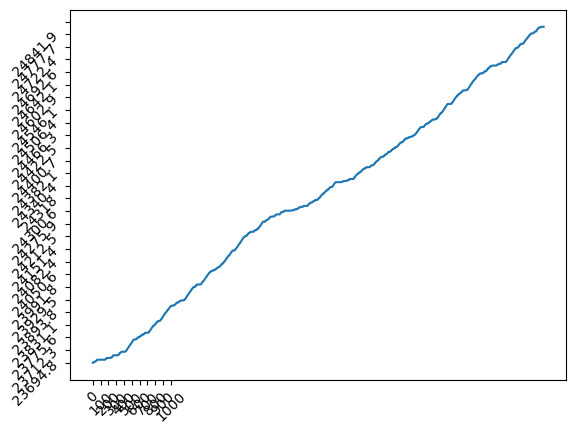

In [34]:
x_axis=[]
y_axis=[]
date_time=[]
for i in range(0,result_ordered.shape[0]-1):
    x_axis.append(i)
    y_axis.append(result_ordered.iloc[i,20])
    date_time.append(result_ordered.iloc[i,31])

print(min(x_axis),max(x_axis),min(y_axis),max(y_axis),date_time[max(x_axis)])

plt.xticks(range(0,1010,100),rotation=45)
plt.yticks(range(0,65800,100),rotation=45)
plt.plot(x_axis,y_axis)

0 5781 0.0 97.6 20260617185712.0


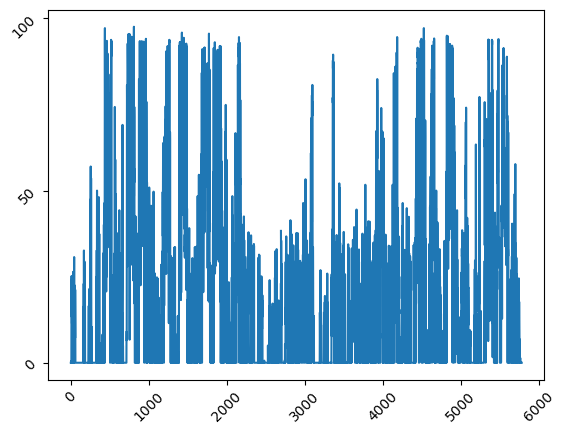

In [35]:
x_axis=[]
y_axis=[]
date_time=[]
for i in range(0,result_ordered.shape[0]-1):
    x_axis.append(i)
    y_axis.append(result_ordered.iloc[i,35])
    date_time.append(result_ordered.iloc[i,31])

print(min(x_axis),max(x_axis),min(y_axis),max(y_axis),date_time[max(x_axis)])

plt.xticks(range(0,23282,1000),rotation=45)
plt.yticks(range(0,285,50),rotation=45)
plt.plot(x_axis,y_axis)

¡Carlos Morante put a filter to keep raw data without  processing if the speed is very high!

In [36]:
for i in range(0,len(y_axis)):
    if y_axis[i]>0:
        print(y_axis[i],' -> ',date_time[i])

0.5  ->  20260601153200.0
0.5  ->  20260601153200.0
23.6  ->  20260601154123.0
23.6  ->  20260601154123.0
25.2  ->  20260601154143.0
17.3  ->  20260601154201.0
24.2  ->  20260601154216.0
13.3  ->  20260601154255.0
22.5  ->  20260601154301.0
11.4  ->  20260601154316.0
19.4  ->  20260601154319.0
0.8  ->  20260601154520.0
0.8  ->  20260601154520.0
20.6  ->  20260601163813.0
20.6  ->  20260601163813.0
26.4  ->  20260601163840.0
18.1  ->  20260601163901.0
22.6  ->  20260601163904.0
6.4  ->  20260601164004.0
10.5  ->  20260601164104.0
17.7  ->  20260601164110.0
9.7  ->  20260601164122.0
12.5  ->  20260601164140.0
16.3  ->  20260601164529.0
25.9  ->  20260601164532.0
30.7  ->  20260601164535.0
22.3  ->  20260601164659.0
12.7  ->  20260601164705.0
15.8  ->  20260601164711.0
5.2  ->  20260601164805.0
10.0  ->  20260601164826.0
12.7  ->  20260601164905.0
14.7  ->  20260601164917.0
5.2  ->  20260601164938.0
22.4  ->  20260601164944.0
15.2  ->  20260601165004.0
7.2  ->  20260601165104.0
21.2  ->  